🌾 AGRIVISION AI - CROP RECOMMENDATION MODEL

📥 Downloading Crop Recommendation Dataset...
Using Colab cache for faster access to the 'crop-recommendation-dataset' dataset.

✅ Dataset downloaded!
📁 Location: /kaggle/input/crop-recommendation-dataset

📄 CSV files found:
    /kaggle/input/crop-recommendation-dataset/Crop_recommendation.csv

✅ Using dataset: /kaggle/input/crop-recommendation-dataset/Crop_recommendation.csv


📊 DATASET INFORMATION

Dataset shape: (2200, 8)

Columns:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

First 5 records:
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice

Cleaned columns:
['n', 'p', 'k',

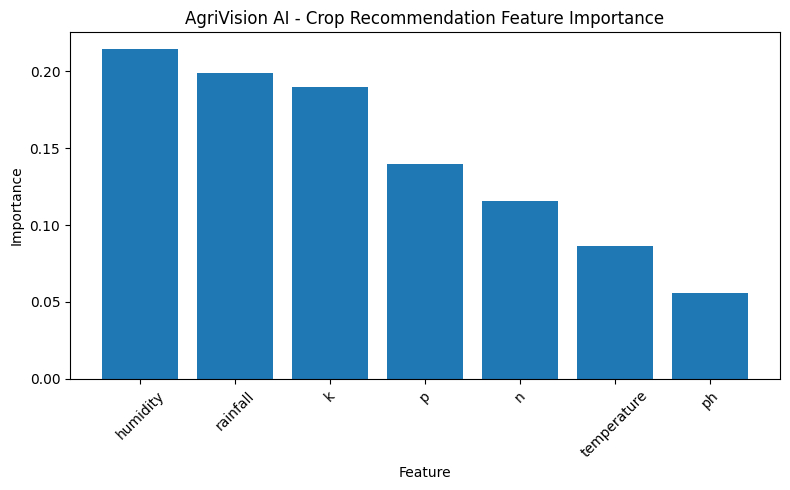


✅ Best model saved:
/content/crop_recommendation_model.pkl
✅ Label encoder saved:
/content/crop_label_encoder.pkl
✅ Feature order saved:
/content/crop_features.pkl
✅ Scaler saved:
/content/crop_scaler.pkl
✅ Model information saved:
/content/crop_model_info.json


🧪 TESTING MODEL WITH SAMPLE FARM

INPUT
----------------------------------------
N           : 90
P           : 42
K           : 43
Temperature : 25
Humidity    : 82
pH          : 6.5
Rainfall    : 200

🌾 RESULT
----------------------------------------
Recommended Crop: JUTE
Confidence: 60.0%

Top 3 recommendations:
🌱 jute            → 60.00%
🌱 rice            → 39.33%
🌱 papaya          → 0.67%


🎉 AGRIVISION AI CROP MODEL COMPLETE


MODEL TYPE
----------
Machine Learning Classification


INPUTS
------
1. Nitrogen (N)
2. Phosphorus (P)
3. Potassium (K)
4. Temperature
5. Humidity
6. pH
7. Rainfall


OUTPUT
------
Recommended Crop
Confidence
Top 3 Crops


MODELS TESTED
-------------
Random Forest
Extra Trees
XGBoost
Decision Tr

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📥 Downloading label encoder...


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>


📥 Downloading model info...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 ALL DONE!


In [1]:
# =====================================================================
# 🌾 AGRIVISION AI - CROP RECOMMENDATION
# COMPLETE GOOGLE COLAB CODE - RUN IN ONE CELL
#
# Input:
# N, P, K, Temperature, Humidity, pH, Rainfall
#
# Output:
# Recommended Crop + Confidence
#
# Models:
# 1. Random Forest
# 2. Extra Trees
# 3. XGBoost
# 4. Decision Tree
# 5. KNN
#
# Final deployment:
# Flutter → FastAPI → .pkl Model
# =====================================================================


# =====================================================================
# 1. INSTALL PACKAGES
# =====================================================================

!pip install -q kagglehub scikit-learn xgboost joblib


# =====================================================================
# 2. IMPORT LIBRARIES
# =====================================================================

import os
import glob
import json
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")


print("=" * 70)
print("🌾 AGRIVISION AI - CROP RECOMMENDATION MODEL")
print("=" * 70)


# =====================================================================
# 3. SETTINGS
# =====================================================================

RANDOM_STATE = 42

TEST_SIZE = 0.20


FEATURES = [
    "n",
    "p",
    "k",
    "temperature",
    "humidity",
    "ph",
    "rainfall"
]


# =====================================================================
# 4. DOWNLOAD DATASET AUTOMATICALLY
# =====================================================================

print("\n📥 Downloading Crop Recommendation Dataset...")


dataset_path = kagglehub.dataset_download(
    "atharvaingle/crop-recommendation-dataset"
)


print("\n✅ Dataset downloaded!")

print(
    "📁 Location:",
    dataset_path
)


# =====================================================================
# 5. FIND CSV AUTOMATICALLY
# =====================================================================

csv_files = glob.glob(
    os.path.join(
        dataset_path,
        "**",
        "*.csv"
    ),
    recursive=True
)


if len(csv_files) == 0:

    raise RuntimeError(
        "❌ CSV file not found!"
    )


print("\n📄 CSV files found:")


for file in csv_files:

    print(
        "   ",
        file
    )


# Use first CSV
csv_path = csv_files[0]


print(
    "\n✅ Using dataset:",
    csv_path
)


# =====================================================================
# 6. LOAD DATASET
# =====================================================================

df = pd.read_csv(
    csv_path
)


print("\n")
print("=" * 70)
print("📊 DATASET INFORMATION")
print("=" * 70)


print(
    "\nDataset shape:",
    df.shape
)


print(
    "\nColumns:"
)

print(
    df.columns.tolist()
)


print(
    "\nFirst 5 records:"
)

print(
    df.head()
)


# =====================================================================
# 7. CLEAN COLUMN NAMES
# =====================================================================

df.columns = [

    column
    .strip()
    .lower()

    for column in df.columns
]


print(
    "\nCleaned columns:"
)

print(
    df.columns.tolist()
)


# =====================================================================
# 8. FIND TARGET COLUMN
# =====================================================================

possible_targets = [

    "label",
    "crop",
    "crop_name",
    "cropname"
]


TARGET = None


for column in possible_targets:

    if column in df.columns:

        TARGET = column

        break


if TARGET is None:

    raise RuntimeError(
        "❌ Crop target column not found!"
    )


print(
    "\n🎯 Target column:",
    TARGET
)


# =====================================================================
# 9. VERIFY FEATURES
# =====================================================================

missing_features = [

    feature

    for feature in FEATURES

    if feature not in df.columns
]


if missing_features:

    raise RuntimeError(

        "❌ Missing features: "

        + str(
            missing_features
        )

    )


print(
    "\n✅ All 7 required features found!"
)


# =====================================================================
# 10. DATA CLEANING
# =====================================================================

print("\n🧹 Cleaning dataset...")


print(
    "Missing values before cleaning:",
    df.isnull().sum().sum()
)


print(
    "Duplicate rows:",
    df.duplicated().sum()
)


# Remove missing values

df = df.dropna()


# Remove duplicates

df = df.drop_duplicates()


# Reset index

df = df.reset_index(
    drop=True
)


print(
    "\n✅ Final dataset shape:",
    df.shape
)


# =====================================================================
# 11. DATASET STATISTICS
# =====================================================================

print("\n")
print("=" * 70)
print("🌱 CROP INFORMATION")
print("=" * 70)


crop_counts = df[
    TARGET
].value_counts()


print(
    "\nNumber of crop classes:",
    df[TARGET].nunique()
)


print(
    "\nCrop distribution:"
)


print(
    crop_counts
)


# =====================================================================
# 12. CREATE INPUT AND OUTPUT
# =====================================================================

X = df[
    FEATURES
].copy()


y_text = (
    df[TARGET]
    .astype(str)
    .str.strip()
)


print(
    "\nInput shape:",
    X.shape
)


print(
    "Output shape:",
    y_text.shape
)


# =====================================================================
# 13. LABEL ENCODING
# =====================================================================

label_encoder = LabelEncoder()


y = label_encoder.fit_transform(
    y_text
)


print(
    "\n🏷️ Crop classes:"
)


for index, crop in enumerate(
    label_encoder.classes_
):

    print(
        f"{index:2d} → {crop}"
    )


print(
    "\nTotal classes:",
    len(label_encoder.classes_)
)


# =====================================================================
# 14. TRAIN TEST SPLIT
# =====================================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=TEST_SIZE,

    random_state=RANDOM_STATE,

    stratify=y

)


print("\n")
print("=" * 70)
print("📊 TRAIN / TEST SPLIT")
print("=" * 70)


print(
    "Training samples:",
    len(X_train)
)


print(
    "Testing samples:",
    len(X_test)
)


# =====================================================================
# 15. SCALER FOR KNN
# =====================================================================

# Tree-based models don't need scaling.
# KNN performs better with scaled features.

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)


X_test_scaled = scaler.transform(
    X_test
)


# =====================================================================
# 16. DEFINE MODELS
# =====================================================================

models = {


    "Random Forest":

        RandomForestClassifier(

            n_estimators=300,

            max_features="sqrt",

            random_state=RANDOM_STATE,

            n_jobs=-1

        ),


    "Extra Trees":

        ExtraTreesClassifier(

            n_estimators=300,

            random_state=RANDOM_STATE,

            n_jobs=-1

        ),


    "XGBoost":

        xgb.XGBClassifier(

            n_estimators=200,

            max_depth=6,

            learning_rate=0.1,

            subsample=0.9,

            colsample_bytree=0.9,

            objective="multi:softprob",

            eval_metric="mlogloss",

            random_state=RANDOM_STATE,

            n_jobs=-1

        ),


    "Decision Tree":

        DecisionTreeClassifier(

            random_state=RANDOM_STATE

        ),


    "KNN":

        KNeighborsClassifier(

            n_neighbors=5

        )

}


# =====================================================================
# 17. TRAIN MODELS
# =====================================================================

print("\n")
print("=" * 70)
print("🚀 TRAINING MACHINE LEARNING MODELS")
print("=" * 70)


results = {}

trained_models = {}


for name, model in models.items():


    print(
        f"\n🧠 Training {name}..."
    )


    # KNN needs scaled data

    if name == "KNN":

        model.fit(
            X_train_scaled,
            y_train
        )


        predictions = model.predict(
            X_test_scaled
        )


    else:

        model.fit(
            X_train,
            y_train
        )


        predictions = model.predict(
            X_test
        )


    accuracy = accuracy_score(

        y_test,

        predictions

    )


    results[name] = accuracy

    trained_models[name] = model


    print(

        f"✅ {name} Accuracy: "

        f"{accuracy * 100:.2f}%"

    )


# =====================================================================
# 18. MODEL COMPARISON
# =====================================================================

print("\n")
print("=" * 70)
print("🏆 MODEL COMPARISON")
print("=" * 70)


sorted_results = sorted(

    results.items(),

    key=lambda item: item[1],

    reverse=True

)


for rank, (name, accuracy) in enumerate(
    sorted_results,
    start=1
):


    print(

        f"{rank}. "

        f"{name:20s}"

        f" → "

        f"{accuracy * 100:.2f}%"

    )


# =====================================================================
# 19. SELECT BEST MODEL
# =====================================================================

best_model_name = sorted_results[
    0
][0]


best_accuracy = sorted_results[
    0
][1]


best_model = trained_models[
    best_model_name
]


print("\n🥇 BEST MODEL")

print(
    "Model:",
    best_model_name
)


print(

    f"Test Accuracy: "

    f"{best_accuracy * 100:.2f}%"

)


# =====================================================================
# 20. BEST MODEL PREDICTIONS
# =====================================================================

if best_model_name == "KNN":


    best_predictions = (
        best_model.predict(
            X_test_scaled
        )
    )


else:


    best_predictions = (
        best_model.predict(
            X_test
        )
    )


# =====================================================================
# 21. CLASSIFICATION REPORT
# =====================================================================

print("\n")
print("=" * 70)
print("📋 CLASSIFICATION REPORT")
print("=" * 70)


print(

    classification_report(

        y_test,

        best_predictions,

        target_names=(
            label_encoder.classes_
        ),

        zero_division=0

    )

)


# =====================================================================
# 22. CONFUSION MATRIX
# =====================================================================

cm = confusion_matrix(

    y_test,

    best_predictions

)


print(
    "\nConfusion Matrix Shape:",
    cm.shape
)


# =====================================================================
# 23. FEATURE IMPORTANCE
# =====================================================================

if hasattr(
    best_model,
    "feature_importances_"
):


    importance = (
        best_model
        .feature_importances_
    )


    importance_df = pd.DataFrame({

        "Feature":
            FEATURES,

        "Importance":
            importance

    })


    importance_df = (
        importance_df
        .sort_values(
            by="Importance",
            ascending=False
        )
    )


    print("\n")
    print("=" * 70)
    print("🌾 FEATURE IMPORTANCE")
    print("=" * 70)


    print(
        importance_df
    )


    # ---------------------------------------------------------
    # Plot
    # ---------------------------------------------------------

    plt.figure(
        figsize=(8, 5)
    )


    plt.bar(

        importance_df[
            "Feature"
        ],

        importance_df[
            "Importance"
        ]

    )


    plt.xlabel(
        "Feature"
    )


    plt.ylabel(
        "Importance"
    )


    plt.title(
        "AgriVision AI - Crop Recommendation Feature Importance"
    )


    plt.xticks(
        rotation=45
    )


    plt.tight_layout()


    plt.show()


# =====================================================================
# 24. SAVE BEST MODEL
# =====================================================================

MODEL_PATH = (
    "/content/"
    "crop_recommendation_model.pkl"
)


joblib.dump(

    best_model,

    MODEL_PATH

)


print(
    "\n✅ Best model saved:"
)

print(
    MODEL_PATH
)


# =====================================================================
# 25. SAVE LABEL ENCODER
# =====================================================================

ENCODER_PATH = (
    "/content/"
    "crop_label_encoder.pkl"
)


joblib.dump(

    label_encoder,

    ENCODER_PATH

)


print(
    "✅ Label encoder saved:"
)

print(
    ENCODER_PATH
)


# =====================================================================
# 26. SAVE FEATURE ORDER
# =====================================================================

FEATURE_PATH = (
    "/content/"
    "crop_features.pkl"
)


joblib.dump(

    FEATURES,

    FEATURE_PATH

)


print(
    "✅ Feature order saved:"
)

print(
    FEATURE_PATH
)


# =====================================================================
# 27. SAVE SCALER IF KNN WINS
# =====================================================================

SCALER_PATH = (
    "/content/"
    "crop_scaler.pkl"
)


joblib.dump(

    scaler,

    SCALER_PATH

)


print(
    "✅ Scaler saved:"
)

print(
    SCALER_PATH
)


# =====================================================================
# 28. SAVE MODEL INFORMATION
# =====================================================================

MODEL_INFO_PATH = (
    "/content/"
    "crop_model_info.json"
)


model_info = {

    "model":
        best_model_name,

    "accuracy":
        float(best_accuracy),

    "features":
        FEATURES,

    "number_of_classes":
        int(
            len(
                label_encoder.classes_
            )
        ),

    "classes":
        label_encoder
        .classes_
        .tolist(),

    "requires_scaling":
        best_model_name == "KNN"

}


with open(

    MODEL_INFO_PATH,

    "w"

) as f:


    json.dump(

        model_info,

        f,

        indent=4

    )


print(
    "✅ Model information saved:"
)

print(
    MODEL_INFO_PATH
)


# =====================================================================
# 29. CREATE PREDICTION FUNCTION
# =====================================================================

def predict_crop(

    N,

    P,

    K,

    temperature,

    humidity,

    ph,

    rainfall

):


    # Create input with EXACT training column order

    sample = pd.DataFrame(

        [[

            N,

            P,

            K,

            temperature,

            humidity,

            ph,

            rainfall

        ]],

        columns=FEATURES

    )


    # ---------------------------------------------------------
    # Scaling if KNN won
    # ---------------------------------------------------------

    if best_model_name == "KNN":

        model_input = scaler.transform(
            sample
        )

    else:

        model_input = sample


    # ---------------------------------------------------------
    # Prediction
    # ---------------------------------------------------------

    prediction = best_model.predict(
        model_input
    )[0]


    crop = (
        label_encoder
        .inverse_transform(
            [prediction]
        )[0]
    )


    # ---------------------------------------------------------
    # Probability
    # ---------------------------------------------------------

    probabilities = (
        best_model.predict_proba(
            model_input
        )[0]
    )


    confidence = float(
        np.max(
            probabilities
        )
    )


    # ---------------------------------------------------------
    # Top 3
    # ---------------------------------------------------------

    top_indices = np.argsort(
        probabilities
    )[-3:][::-1]


    top_3 = []


    for index in top_indices:


        crop_name = (
            label_encoder
            .inverse_transform(
                [index]
            )[0]
        )


        probability = float(
            probabilities[index]
        )


        top_3.append({

            "crop":
                crop_name,

            "confidence":
                round(
                    probability * 100,
                    2
                )

        })


    return {

        "recommended_crop":
            crop,

        "confidence":
            round(
                confidence * 100,
                2
            ),

        "top_3":
            top_3

    }


# =====================================================================
# 30. TEST SAMPLE
# =====================================================================

print("\n")
print("=" * 70)
print("🧪 TESTING MODEL WITH SAMPLE FARM")
print("=" * 70)


result = predict_crop(

    N=90,

    P=42,

    K=43,

    temperature=25,

    humidity=82,

    ph=6.5,

    rainfall=200

)


print("\nINPUT")
print("-" * 40)

print("N           :", 90)
print("P           :", 42)
print("K           :", 43)
print("Temperature :", 25)
print("Humidity    :", 82)
print("pH          :", 6.5)
print("Rainfall    :", 200)


print("\n🌾 RESULT")
print("-" * 40)


print(

    "Recommended Crop:",

    result[
        "recommended_crop"
    ].upper()

)


print(

    "Confidence:",

    str(
        result[
            "confidence"
        ]
    )

    + "%"

)


print(
    "\nTop 3 recommendations:"
)


for recommendation in result[
    "top_3"
]:


    print(

        f"🌱 "

        f"{recommendation['crop']:15s}"

        f" → "

        f"{recommendation['confidence']:.2f}%"

    )


# =====================================================================
# 31. FINAL SUMMARY
# =====================================================================

print("\n")
print("=" * 70)
print("🎉 AGRIVISION AI CROP MODEL COMPLETE")
print("=" * 70)


print(

f"""

MODEL TYPE
----------
Machine Learning Classification


INPUTS
------
1. Nitrogen (N)
2. Phosphorus (P)
3. Potassium (K)
4. Temperature
5. Humidity
6. pH
7. Rainfall


OUTPUT
------
Recommended Crop
Confidence
Top 3 Crops


MODELS TESTED
-------------
Random Forest
Extra Trees
XGBoost
Decision Tree
KNN


BEST MODEL
----------
{best_model_name}


TEST ACCURACY
-------------
{best_accuracy * 100:.2f}%


DEPLOYMENT
----------

Flutter
   ↓
HTTP POST
   ↓
FastAPI
   ↓
crop_recommendation_model.pkl
   ↓
Prediction
   ↓
Recommended Crop


FILES CREATED
-------------

1. crop_recommendation_model.pkl

2. crop_label_encoder.pkl

3. crop_features.pkl

4. crop_scaler.pkl

5. crop_model_info.json

"""

)


print("=" * 70)


# =====================================================================
# 32. DOWNLOAD FILES
# =====================================================================

from google.colab import files


print(
    "\n📥 Downloading model..."
)

files.download(
    MODEL_PATH
)


print(
    "\n📥 Downloading label encoder..."
)

files.download(
    ENCODER_PATH
)


print(
    "\n📥 Downloading feature information..."
)

files.download(
    FEATURE_PATH
)


print(
    "\n📥 Downloading scaler..."
)

files.download(
    SCALER_PATH
)


print(
    "\n📥 Downloading model info..."
)

files.download(
    MODEL_INFO_PATH
)


print(
    "\n🎉 ALL DONE!"
)